In [ ]:
# =============================================================================
# IMPORTS
# =============================================================================
import os
import shutil
import math
import numpy as np
from scipy.ndimage import distance_transform_edt, gaussian_filter, binary_fill_holes, label
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr
from PIL import Image
from skimage import measure
from skimage.io import imshow
from sklearn.decomposition import PCA
from sklearn.neighbors import KDTree
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from google.colab import drive
import pandas as pd
from torch.utils.data.sampler import SubsetRandomSampler
from sklearn.cluster import KMeans


In [ ]:
# =============================================================================
# ENVIRONMENT SETUP — Google Colab
# =============================================================================
# Only required if training. Mounting Drive is what gives the notebook access
# to the image dataset; skip this cell if you are loading pretrained weights.
# Running locally: skip the mount and point PROJECT_PATH at the repo root.
# =============================================================================

drive.mount('/content/drive')
PROJECT_PATH = "/content/drive/MyDrive/SliceLearn_Code"
os.chdir(PROJECT_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip datasets/undamaged.zip -d datasets/undamaged_wings

In [ ]:
# =============================================================================
# DATASET SPLIT — build train/val/test folders from CSV
# =============================================================================
# Run-once preprocessing. Reads datasets/dataset_splits.csv, which lists every
# image and a boolean column per split, and copies each image into the
# folder(s) it belongs to. Files are copied (not moved), so undamaged_wings/
# stays intact and splits may overlap (train_50 / train_10 are subsets of
# train). Self-contained: safe to skip entirely if the split folders already
# exist. All inputs and outputs live under PROJECT_PATH/datasets/.
# =============================================================================

DATA_ROOT = "datasets"

csv_path = os.path.join(DATA_ROOT, "dataset_splits.csv")
source_dir = os.path.join(DATA_ROOT, "undamaged_wings")

split_columns = ["train", "train_50", "train_10", "val", "test"]

# split name -> output folder, all under datasets/
output_dirs = {name: os.path.join(DATA_ROOT, name) for name in split_columns}


def is_true(value):
    """Parse a CSV cell as a boolean. Accepts True/1/yes in any case."""
    return str(value).strip().lower() in ["true", "1", "yes"]


df = pd.read_csv(csv_path)

for folder in output_dirs.values():
    os.makedirs(folder, exist_ok=True)

for _, row in df.iterrows():
    filename = row["Filename"]
    src_path = os.path.join(source_dir, filename)

    if not os.path.exists(src_path):
        print(f"Missing file: {src_path}")   # reported, not fatal
        continue

    for col in split_columns:
        if is_true(row[col]):
            shutil.copy2(src_path, os.path.join(output_dirs[col], filename))

print("Done copying files.")

Done copying files.


In [ ]:
# =============================================================================
# CONFIGURATION
# =============================================================================
S = 1001              # canvas resolution (SxS grid)
SEED = 0              # global random seed for reproducibility
TARGET_SIZE = 0.4     # normalized shape size after alignment
ROOT_CROP_X = -0.8    # x below which the wing root is cropped, in grid units

DATA_ROOT = "datasets"    # images, splits
OUTPUT_ROOT = "outputs"   # distance matrices, trained models, results

N_VAL_TO_USE = 20     # validation wings used downstream; lower for a faster run

np.random.seed(SEED)
os.makedirs(OUTPUT_ROOT, exist_ok=True)
# =============================================================================


# =============================================================================
# FUNCTIONS
# =============================================================================
# Array conventions used throughout:
#   grid   : (S, S, 3) — channels are (x, y, value); x, y in [-1, 1]
#   shape  : (N, 2)    — xy coordinates of the "on" pixels only
#   sdf    : (S, S, 3) — channels are (x, y, signed distance)
#
# S is the canvas resolution and is FIXED for a given pipeline. It is read from
# the CONFIGURATION cell above rather than passed as an argument, so that cell
# must be executed before any function here is called.
# =============================================================================

# Loads an image, binarizes it (non-white pixels = foreground), fills interior
# holes, and centers it in an SxS canvas with zero-padding.
def pad_wing(path):
    img = np.array(Image.open(path).convert("RGB"))
    binary = (~np.all(img >= 250, axis=-1)).astype(np.uint8)   # white background -> 0
    binary = binary_fill_holes(binary).astype(np.uint8)
    h, w = binary.shape
    if h > S or w > S:
        raise ValueError(f"Image ({h},{w}) is larger than target size S={S}")
    pad_top    = (S - h) // 2
    pad_bottom = S - h - pad_top
    pad_left   = (S - w) // 2
    pad_right  = S - w - pad_left
    padded = np.pad(binary, ((pad_top, pad_bottom), (pad_left, pad_right)),
                    mode='constant', constant_values=0)
    return padded


# Creates an SxS grid of (x, y) coordinates spanning [-1, 1] in both axes.
def make_square_grid():
    xs = np.linspace(-1, 1, S)
    ys = np.linspace(-1, 1, S)
    X, Y = np.meshgrid(xs, ys)
    coords = np.stack([X, Y], axis=-1)   # (S, S, 2)
    return coords


# Attaches a padded binary image to a coordinate grid as a third channel.
# The vertical flip reconciles array row order (top-down) with grid y (bottom-up).
def move_image_to_grid(set_grid, img):
    img_flipped = img[::-1, :]
    return np.concatenate([set_grid, img_flipped[..., None].astype(np.uint8)], axis=-1)


# Extracts the foreground pixels from a grid and returns their (x, y) coords.
def get_shape(grid):
    return grid[grid[:, :, 2] > 0][:, :2]


# Shape volume = number of foreground pixels.
def compute_volume(shape):
    return float(shape.shape[0])


# Centroid (mean position) of the foreground pixels.
def compute_centroid(shape):
    V = compute_volume(shape)
    sum_x = shape[:, 0].sum()
    sum_y = shape[:, 1].sum()
    center = np.array([sum_x / V, sum_y / V])
    return center


# 2x2 covariance matrix of the foreground pixel positions about the centroid.
def compute_covariance(shape):
    V = compute_volume(shape)
    beta = compute_centroid(shape)
    coords_shift = shape - beta
    cov_mat = (coords_shift.T @ coords_shift) / V
    return cov_mat


# Scalar size measure: sqrt of the covariance trace (total spread about centroid).
def compute_size(shape):
    return float(np.sqrt(np.trace(compute_covariance(shape))))


# Computes the similarity transform (scale lam, rotation R, translation t) that
# normalizes a shape to `target_size` and orients it along its principal axes.
# Eigenvectors from eigh come in ascending eigenvalue order, so columns are
# swapped to put the major axis first. `flip` fixes the sign ambiguity of the
# eigenvectors, i.e. which way the shape ends up facing; the default (-1, -1)
# is specific to this wing dataset and will need adjusting for other data.
def compute_alignment(shape, target_size=TARGET_SIZE, flip=(-1, -1)):
    beta = compute_centroid(shape)
    gamma = compute_size(shape)
    lam = target_size / gamma
    _, V = np.linalg.eigh(compute_covariance(shape))
    V = V[:, [1, 0]]
    V[:, 0] *= flip[0]
    V[:, 1] *= flip[1]
    R = V.T
    t = -lam * (R @ beta)
    return lam, R, t


# Applies an alignment transform by inverse warping: each output grid point is
# mapped back into source coordinates and filled by nearest-neighbor lookup.
def transform_on_set_grid(set_grid, img, lam, R, t):
    Ycoords = set_grid.reshape(-1, 2)
    Xquery = ((Ycoords - t) @ R) / lam
    src_coords = img[:, :, :2].reshape(-1, 2)
    src_vals   = img[:, :, 2].reshape(-1)
    tree = KDTree(src_coords)
    _, idx = tree.query(Xquery, k=1)
    idx = idx[:, 0]
    sampled_vals = src_vals[idx]
    out = np.concatenate([Ycoords, sampled_vals[:, None]], axis=1)
    return out.reshape(S, S, 3)


# Signed distance field of a binary shape: negative inside, positive outside,
# in grid units. `root` optionally zeroes everything left of that x value
# before the transform (removes the wing root).
def compute_sdf(grid, root=None):
    coords = grid[:, :, :2]
    vals = grid[:, :, 2].copy()
    if root is not None:
        xcoords = coords[:, :, 0]
        vals[xcoords < root] = 0
    mask = vals > 0
    d = 2.0 / (S - 1)                                    # grid spacing
    dist_out = distance_transform_edt(~mask, sampling=(d, d))
    dist_in  = distance_transform_edt(mask,  sampling=(d, d))
    sdf = dist_out - dist_in
    sdf_bin = np.concatenate([coords, sdf[..., None]], axis=-1)
    return sdf_bin


# Draws training points from an SDF field, oversampling the surface: `percent`
# of samples come from the narrow band |sdf| < epsilon, the rest uniformly from
# the whole grid. Returns (num_samples, 3) rows of (x, y, sdf).
# If the band is empty (degenerate mask), all samples are drawn uniformly.
def sample_sdf_points(sdf, epsilon=0.05, num_samples=5000, percent=0.5):
    coords_vals = sdf.reshape(-1, 3)
    sdf_vals = coords_vals[:, 2]
    band_mask = np.abs(sdf_vals) < epsilon
    band_points = coords_vals[band_mask]
    all_points = coords_vals
    n_band = int(num_samples * percent)
    if len(band_points) == 0:                # no surface found -> uniform only
        n_band = 0
    n_uniform = num_samples - n_band

    samples_list = []
    if n_band > 0:
        replace_band = len(band_points) < n_band
        band_idx = np.random.choice(len(band_points), size=n_band, replace=replace_band)
        samples_list.append(band_points[band_idx])
    if n_uniform > 0:
        replace_uniform = len(all_points) < n_uniform
        uniform_idx = np.random.choice(len(all_points), size=n_uniform, replace=replace_uniform)
        samples_list.append(all_points[uniform_idx])

    samples = np.concatenate(samples_list, axis=0)
    np.random.shuffle(samples)
    return samples

# Preprocesses every PNG in a directory: pad to the SxS canvas, attach to the
# coordinate grid, then align (centre, scale to target_size, orient along the
# principal axes). Intermediates are discarded; only the aligned grids are
# returned, alongside the filenames in sorted order.
def preprocess_split(directory, set_grid, target_size=TARGET_SIZE):
    files = sorted(f for f in os.listdir(directory) if f.lower().endswith(".png"))
    normalized_all = []
    for file in files:
        path = os.path.join(directory, file)
        binary = pad_wing(path)
        coord = move_image_to_grid(set_grid, binary)
        shape = get_shape(coord)
        lam, R, t = compute_alignment(shape, target_size=target_size)
        normalized_all.append(transform_on_set_grid(set_grid, coord, lam, R, t))
    return files, normalized_all

# Pairwise distance matrix between SDFs, returning an (n, n) symmetric array.
# Distance is the root-mean-square difference between the two fields, which is
# the L2 function norm over the [-1,1]^2 domain up to a constant factor, and is
# independent of grid resolution S.
def compute_l2_sdf_matrix(sdf_list):
    n = len(sdf_list)
    D = np.zeros((n, n))
    for i in range(n):
        Zi = sdf_list[i][:, :, 2]
        for j in range(i + 1, n):          # upper triangle only; matrix is symmetric
            Zj = sdf_list[j][:, :, 2]
            d = np.sqrt(np.mean((Zi - Zj) ** 2))
            D[i, j] = d
            D[j, i] = d
    return D


# Cross distance matrix between two sets of SDFs, returning an
# (len(sdf_list_a), len(sdf_list_b)) array. Row i holds the distances from
# element i of set A to every element of set B. Same metric as
# compute_l2_sdf_matrix.
def compute_l2_sdf_cross_matrix(sdf_list_a, sdf_list_b):
    D = np.zeros((len(sdf_list_a), len(sdf_list_b)))
    for i, sdf_a in enumerate(sdf_list_a):
        Za = sdf_a[:, :, 2]
        for j, sdf_b in enumerate(sdf_list_b):
            Zb = sdf_b[:, :, 2]
            D[i, j] = np.sqrt(np.mean((Za - Zb) ** 2))
    return D


In [ ]:
# =============================================================================
# PREPROCESSING — aligned wings and their SDFs
# =============================================================================
# Phase 1: every PNG is padded to the SxS canvas, attached to the shared
#   coordinate grid, and aligned — centred, scaled to TARGET_SIZE, and oriented
#   along its principal axes. Alignment removes differences in position, scale
#   and rotation, so downstream comparisons reflect wing form rather than how
#   the specimen happened to be photographed.
#
# Phase 2: each aligned wing is converted to a signed distance field (negative
#   inside the shape, positive outside). The wing root is cropped at
#   x < ROOT_CROP_X before the transform, so the SDF describes the wing blade
#   only. The shape is recoverable at any time as sdf <= 0.
#
# Only aligned grids and their SDFs are kept; raw binaries and unaligned grids
# are intermediates and are not retained.
# Requires the split folders produced by the DATASET SPLIT cell.
# =============================================================================

set_grid = make_square_grid()

train_dir = os.path.join(DATA_ROOT, "train")
val_dir   = os.path.join(DATA_ROOT, "val")

# --- Phase 1: load and align ---
train_files, train_normalized = preprocess_split(train_dir, set_grid)
val_files,   val_normalized   = preprocess_split(val_dir,   set_grid)

# --- Phase 2: signed distance fields (root-cropped) ---
train_sdfs = [compute_sdf(grid, root=ROOT_CROP_X) for grid in train_normalized]
val_sdfs   = [compute_sdf(grid, root=ROOT_CROP_X) for grid in val_normalized]

print(f"train: {len(train_files)} wings | val: {len(val_files)} wings")

train: 200 wings | val: 50 wings


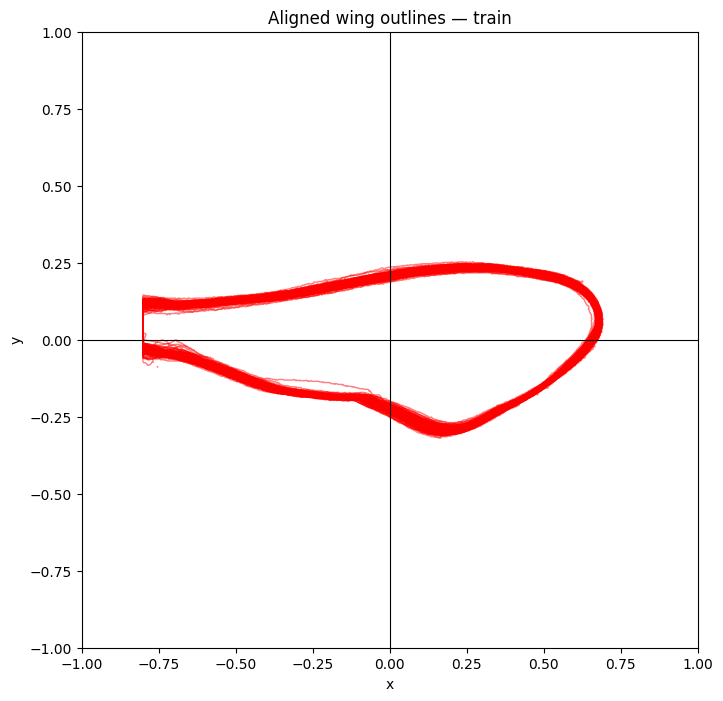

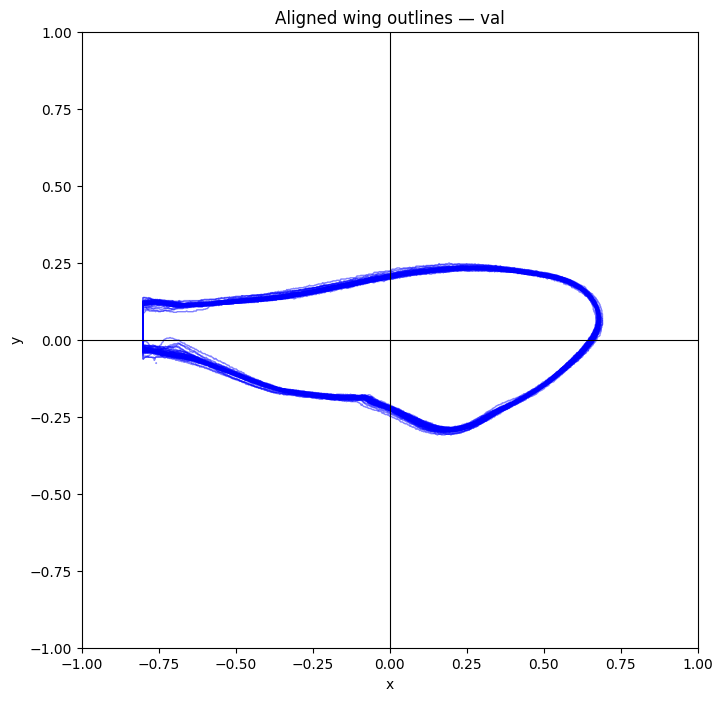

In [ ]:
# =============================================================================
# SANITY CHECK — alignment
# =============================================================================
# Overlays the outline (SDF zero-contour) of every wing in a split. If
# alignment succeeded the outlines form a tight bundle centred on the origin
# with a common orientation; an outlier curve indicates a wing that was
# mis-oriented, badly segmented, or flipped by the eigenvector sign ambiguity
# (see `flip` in compute_alignment). Diagnostic only — nothing downstream
# depends on this cell, so it can be skipped.
# =============================================================================

for sdfs, color, split in [(train_sdfs, 'red', 'train'), (val_sdfs, 'blue', 'val')]:
    fig, ax = plt.subplots(figsize=(8, 8))
    for sdf in sdfs:
        ax.contour(sdf[:, :, 0], sdf[:, :, 1], sdf[:, :, 2],
                   levels=[0], colors=color, linewidths=1, alpha=0.5)

    ax.axhline(0, color='black', linewidth=0.8)   # coordinate axes for reference
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect('equal')
    ax.set_title(f'Aligned wing outlines — {split}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.show()

In [ ]:
# =============================================================================
# DISTANCE MATRICES — shape dissimilarity between wings
# =============================================================================
# D_train : (n_train, n_train) distances among the training wings.
# D_val   : (n_val, n_train)   distances from each validation wing to every
#                              training wing — row i is validation wing i.
#
# Distances are computed on the root-cropped, aligned SDFs, so they measure
# blade shape difference only. Both matrices are saved to OUTPUT_ROOT so this
# cell (the most expensive in the pipeline) need only be run once.
#
# The validation set is then truncated to the first N_VAL_TO_USE wings, which
# allows a faster partial run without recomputing anything; set
# N_VAL_TO_USE to the full validation size to use all of it.
# =============================================================================

D_train = compute_l2_sdf_matrix(train_sdfs)
D_val   = compute_l2_sdf_cross_matrix(val_sdfs, train_sdfs)

np.save(os.path.join(OUTPUT_ROOT, "D_train.npy"), D_train)
np.save(os.path.join(OUTPUT_ROOT, "D_val.npy"), D_val)

# --- Validation subset used downstream ---
val_files_sub      = val_files[:N_VAL_TO_USE]
val_normalized_sub = val_normalized[:N_VAL_TO_USE]
val_sdfs_sub       = val_sdfs[:N_VAL_TO_USE]
D_val_sub          = D_val[:N_VAL_TO_USE, :]

print(f"D_train: {D_train.shape} | D_val: {D_val.shape} "
      f"| using {len(val_sdfs_sub)} validation wings")

D_train: (200, 200) | D_val: (50, 200) | using 20 validation wings


In [ ]:
# =============================================================================
# MODEL COMPONENTS — dataset, SIREN layers, DeepSDF+SIREN network
# =============================================================================
# Everything in this cell belongs to the learning phase and is independent of
# the geometry utilities above. Reviewers interested only in the model need
# this cell, the hyperparameters cell, and the training loop.
# =============================================================================

# Flat tensor dataset of SDF samples. Each item is one sampled point:
#   (shape_id, coord, distance)
# where shape_id indexes the wing the point came from, coord is its (x, y)
# position, and distance is the ground-truth SDF value there. Stored as three
# contiguous tensors rather than per-point objects, so batching is a slice.
class SDFDataset(Dataset):
    def __init__(self, shape_ids, coords, distances):
        self.shape_ids = torch.as_tensor(shape_ids, dtype=torch.long)
        self.coords    = torch.as_tensor(coords,    dtype=torch.float32)
        self.distances = torch.as_tensor(distances, dtype=torch.float32)

    def __len__(self):
        return self.shape_ids.shape[0]

    def __getitem__(self, idx):
        return self.shape_ids[idx], self.coords[idx], self.distances[idx]


# Draws training points from a list of SDF fields and stacks them into three
# flat arrays. Points are sampled per wing (see sample_sdf_points), then
# concatenated with a shape_id recording which wing each point came from.
def build_sdf_samples(sdf_list, epsilon, num_samples, percent):
    shape_ids, coords, distances = [], [], []
    for shape_idx, sdf in enumerate(sdf_list):
        samples = sample_sdf_points(sdf, epsilon=epsilon,
                                    num_samples=num_samples, percent=percent)
        shape_ids.append(np.full(len(samples), shape_idx, dtype=np.int64))
        coords.append(samples[:, :2])
        distances.append(samples[:, 2])
    return (np.concatenate(shape_ids),
            np.concatenate(coords).astype(np.float32),
            np.concatenate(distances).astype(np.float32))


# A single SIREN layer: linear transform followed by a scaled sine activation.
# Weight initialization depends on the layer's position — the first layer uses
# U(-1/n, 1/n), later layers U(-sqrt(6/n)/omega0, +...) — which is what keeps
# activations well-scaled through the depth of a sine network (Sitzmann et al.,
# 2020). omega0 controls the frequency the layer can represent.
class SineLayer(nn.Module):
    def __init__(self, in_features, out_features, is_first=False, omega0=30.0):
        super().__init__()
        self.in_features = in_features
        self.is_first = is_first
        self.omega0 = omega0
        self.linear = nn.Linear(in_features, out_features)
        self.init_weights()

    def init_weights(self):
        with torch.no_grad():
            if self.is_first:
                self.linear.weight.uniform_(-1 / self.in_features,
                                             1 / self.in_features)
            else:
                bound = math.sqrt(6 / self.in_features) / self.omega0
                self.linear.weight.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega0 * self.linear(x))


# DeepSDF-based network with SIREN activations: maps a latent code plus a 2D coordinate to the
# predicted SDF value at that coordinate. Five sine layers followed by a plain
# linear head (no sine on the output, since SDF values are unbounded).
# NOTE: the constructor defaults below are the values recommended in the SIREN
# paper. The model actually trained here is instantiated with smaller values
# (see the hyperparameters cell) — those are the ones reported.
class SirenDeepSDF2D(nn.Module):
    def __init__(self, latent_dim=16, hidden_dim=256,
                 omega0_first=30.0, omega0_hidden=60.0):
        super().__init__()
        input_dim = latent_dim + 2
        self.l1 = SineLayer(input_dim, hidden_dim, is_first=True, omega0=omega0_first)
        self.l2 = SineLayer(hidden_dim, hidden_dim, omega0=omega0_hidden)
        self.l3 = SineLayer(hidden_dim, hidden_dim, omega0=omega0_hidden)
        self.l4 = SineLayer(hidden_dim, hidden_dim, omega0=omega0_hidden)
        self.l5 = SineLayer(hidden_dim, hidden_dim, omega0=omega0_hidden)
        self.fc_out = nn.Linear(hidden_dim, 1)

        # Output head is linear, so it gets a mild uniform init rather than the
        # SIREN scheme used by the sine layers.
        with torch.no_grad():
            bound = math.sqrt(6 / hidden_dim) * 0.5
            self.fc_out.weight.uniform_(-bound, bound)

    def forward(self, z, coords):
        x = torch.cat([z, coords], dim=1)
        x = self.l1(x)
        x = self.l2(x)
        x = self.l3(x)
        x = self.l4(x)
        x = self.l5(x)
        return self.fc_out(x)

# Normalized stress between latent-space distances and target shape distances:
#   sum((||z_i - z_j|| - D_ij)^2) / sum(D_ij^2)
# This is the quantity minimized (Eq. 2). Kruskal stress-1 is its square root
# and is what gets reported — see the training loop.
# `mask` selects which pairs count (used to drop self-pairs).
def compute_stress(z_a, z_b, D_target, den, mask=None):
    lat_dist = torch.norm(z_a.unsqueeze(1) - z_b.unsqueeze(0), dim=2)
    diff = (lat_dist - D_target).pow(2)
    num = diff[mask].sum() if mask is not None else diff.sum()
    return num / den

# Mean per-wing SDF reconstruction error: the MSE between predicted and true
# SDF values is computed separately for each wing, then averaged over wings.
# Averaging (rather than summing) keeps the value independent of how many wings
# are in the split, so train and validation curves are directly comparable.
def evaluate_sdf_loss(model, codes, ids, coords, dists, num_shapes, device):
    total = 0.0
    for shape_idx in range(num_shapes):
        sel = (ids == shape_idx)
        c = coords[sel]
        d = dists[sel]
        z = codes(torch.tensor([shape_idx], device=device)).expand(len(c), -1)
        pred = model(z, c).squeeze(1)
        total += (pred - d).pow(2).mean().item()
    return total / num_shapes

# Retrieves the latent code for one shape index, shaped (1, latent_dim).
def get_z(latent_codes, shape_idx):
    idx = torch.tensor([shape_idx], dtype=torch.long).to(device)
    return latent_codes(idx)


# Decodes a latent code into a full predicted SDF field by querying the network
# at every point of the coordinate grid. Returns an (S, S, 3) array in the same
# (x, y, value) layout as compute_sdf, so predicted and ground-truth fields can
# be compared or plotted with identical code.
def predicted_sdf(model, z, set_grid):
    model.eval()
    coords_np = set_grid.reshape(-1, 2)
    coords = torch.tensor(coords_np, dtype=torch.float32).to(device)

    if z.dim() == 1:
        z = z.unsqueeze(0)
    z = z.to(device)
    z_rep = z.repeat(coords.shape[0], 1)      # same code for every query point

    with torch.no_grad():
        pred_vals = model(z_rep, coords)

    pred_vals = pred_vals.squeeze().cpu().numpy()
    pred_sdf_flat = np.concatenate([coords_np, pred_vals[:, None]], axis=1)
    return pred_sdf_flat.reshape(S, S, 3)

In [ ]:
# =============================================================================
# TRAINING HYPERPARAMETERS
# =============================================================================
# Every value controlling the learning phase. These are the settings used for
# the results reported in the paper; change them here rather than inline.
# =============================================================================

# --- SDF point sampling ---
SAMPLE_EPSILON  = 0.07    # half-width of the near-surface band, in grid units
SAMPLE_NUM      = 4000    # points sampled per wing
SAMPLE_PERCENT  = 0.4     # fraction drawn from the band; remainder uniform

# --- Architecture ---
LATENT_DIM      = 16      # dimensionality of the per-wing latent code
HIDDEN_DIM      = 128     # width of each SIREN layer
OMEGA0_FIRST    = 30.0    # frequency scale, first layer
OMEGA0_HIDDEN   = 30.0    # frequency scale, hidden layers
LATENT_INIT_STD = 0.01    # std of the normal used to initialize latent codes

# --- Optimization ---
BATCH_SIZE      = 512

# --- Loss weights ---
LAMBDA_DIST = 0.5     # weight on the stress term
SIGMA       = 10      # latent prior scale; latent term is weighted by 1/SIGMA^2

# --- Optimization ---
EPOCHS      = 40
LR          = 1e-4
LR_MIN      = 1e-7    # cosine annealing floor
GRAD_CLIP   = 1.0     # max gradient norm

# --- Validation (test-time latent inference) ---
VAL_EVERY   = 2       # run validation every N epochs
VAL_STEPS   = 40      # optimization steps to fit validation latent codes
VAL_LR      = 1e-4

In [ ]:
# =============================================================================
# TRAINING DATA — sample points from the SDF fields
# =============================================================================
# Each wing is represented not by its full field but by a set of sampled
# points, oversampled near the surface (|sdf| < SAMPLE_EPSILON) so the network
# spends its capacity where the shape boundary actually is. Training uses all
# training wings; validation uses the subset selected earlier.
# =============================================================================

train_ids, train_coords_s, train_dists = build_sdf_samples(
    train_sdfs, SAMPLE_EPSILON, SAMPLE_NUM, SAMPLE_PERCENT)
val_ids, val_coords_s, val_dists = build_sdf_samples(
    val_sdfs_sub, SAMPLE_EPSILON, SAMPLE_NUM, SAMPLE_PERCENT)

train_loader = DataLoader(SDFDataset(train_ids, train_coords_s, train_dists),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SDFDataset(val_ids, val_coords_s, val_dists),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_ids)} from {len(train_sdfs)} wings")
print(f"Val samples:   {len(val_ids)} from {len(val_sdfs_sub)} wings")

Train samples: 800000 from 200 wings
Val samples:   80000 from 20 wings


In [ ]:
# =============================================================================
# MODEL SETUP — network, latent codes, target distances
# =============================================================================
# Latent codes are free parameters, one per training wing, optimized jointly
# with the network (auto-decoder training). Validation wings get no code here;
# theirs are inferred later with the network frozen.
#
# The distance matrices are moved to the device as targets for the stress term,
# which pushes distances between latent codes to match the true L2 distances
# between wing shapes. Only the upper triangle of D_train is used, since it is
# symmetric with a zero diagonal. `den` and `den_val` are the normalizers that
# make the stress loss scale-free.
# =============================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Reproducibility. Drop the cudnn flags if training speed matters more than
# bit-exact repeatability.
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --- Target distances: train-train ---
num_train_wings = len(train_sdfs)
D_tensor = torch.tensor(D_train, dtype=torch.float32).to(device)
mask = torch.triu(torch.ones(num_train_wings, num_train_wings, device=device),
                  diagonal=1).bool()
den = (D_tensor[mask] ** 2).sum().clamp(min=1e-8)

# --- Target distances: val-train ---
N_val = len(val_sdfs_sub)
D_val_tensor = torch.tensor(D_val_sub, dtype=torch.float32).to(device)
den_val = (D_val_tensor ** 2).sum().clamp(min=1e-8)

# --- Model and trainable latent codes ---
latent_codes = nn.Embedding(num_train_wings, LATENT_DIM).to(device)
nn.init.normal_(latent_codes.weight, mean=0.0, std=LATENT_INIT_STD)

model = SirenDeepSDF2D(latent_dim=LATENT_DIM, hidden_dim=HIDDEN_DIM,
                       omega0_first=OMEGA0_FIRST,
                       omega0_hidden=OMEGA0_HIDDEN).to(device)

# --- Loss curve trackers ---
epoch_counter = 0

train_loss_curve = []
train_sdf_loss_curve = []
train_stress_curve = []
train_latent_curve = []

val_loss_curve = []
val_sdf_loss_curve = []
val_stress_curve = []
val_latent_curve = []

Using device: cuda


In [ ]:
# =============================================================================
# TRAINING — auto-decoder with distance-preserving latent space
# =============================================================================
# The network and the training latent codes are optimized jointly. Three terms:
#
#   sdf     — reconstruction: predicted SDF value vs ground truth at each
#             sampled point.
#   latent  — prior keeping codes near the origin, weighted by 1/SIGMA^2.
#   stress  — Kruskal stress-1 between pairwise distances in latent space and
#             the true L2 distances between wing shapes (D_train). This is what
#             makes the latent space metric-faithful rather than arbitrary.
#
# Validation runs every VAL_EVERY epochs. Validation wings have no learned
# codes, so fresh ones are fitted from scratch with the network frozen
# (test-time optimization), measuring how well an unseen wing can be embedded.
# Their stress is measured against the training codes via D_val.
#
# Curves are appended across calls, so re-running this cell continues training
# rather than restarting it.
# =============================================================================

# Sampled points as device tensors, indexed once for per-wing evaluation
train_ids_t    = torch.as_tensor(train_ids, device=device)
train_coords_t = torch.as_tensor(train_coords_s, device=device)
train_dists_t  = torch.as_tensor(train_dists, device=device)
val_ids_t      = torch.as_tensor(val_ids, device=device)
val_coords_t   = torch.as_tensor(val_coords_s, device=device)
val_dists_t    = torch.as_tensor(val_dists, device=device)

optimizer = torch.optim.Adam(
    list(model.parameters()) + list(latent_codes.parameters()), lr=LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=LR_MIN)

col_ids = torch.arange(num_train_wings, device=device).unsqueeze(0)   # (1, N)

for epoch in range(EPOCHS):
    epoch_counter += 1

    # ---------------- TRAINING ----------------
    model.train()
    for shape_ids, coords, distances in train_loader:
        shape_ids = shape_ids.to(device)
        coords    = coords.to(device)
        distances = distances.to(device)

        z = latent_codes(shape_ids)
        pred = model(z, coords).squeeze(1)
        sdf_loss = (pred - distances).pow(2).mean()

        # Terms below act per wing, not per point, so work on unique ids only
        unique_ids = torch.unique(shape_ids)
        z_unique   = latent_codes(unique_ids)
        latent_loss = z_unique.pow(2).sum(dim=1).mean()

        # Stress of this batch's wings against all training wings,
        # excluding each wing's zero distance to itself
        self_mask = (unique_ids.unsqueeze(1) != col_ids)
        dist_loss = compute_stress(z_unique, latent_codes.weight,
                                   D_tensor[unique_ids], den, mask=self_mask)

        loss = sdf_loss + (1 / SIGMA**2) * latent_loss + LAMBDA_DIST * dist_loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(model.parameters()) + list(latent_codes.parameters()),
            max_norm=GRAD_CLIP)
        optimizer.step()

    scheduler.step()

    # ---------------- TRAIN METRICS ----------------
    model.eval()
    with torch.no_grad():
        train_sdf = evaluate_sdf_loss(model, latent_codes, train_ids_t,
                                      train_coords_t, train_dists_t,
                                      num_train_wings, device)
        all_z = latent_codes.weight
        train_latent = all_z.pow(2).sum(dim=1).mean().item()
        train_stress_sq = compute_stress(all_z, all_z, D_tensor, den, mask=mask).item()
        train_stress = np.sqrt(train_stress_sq)      # Kruskal stress-1, reported

    # Total is the objective actually minimized, so it uses the un-rooted term
    train_total = (train_sdf + (1 / SIGMA**2) * train_latent
                   + LAMBDA_DIST * train_stress_sq)

    train_sdf_loss_curve.append(train_sdf)
    train_latent_curve.append(train_latent)
    train_stress_curve.append(train_stress)
    train_loss_curve.append(train_total)

    print(f"Epoch {epoch_counter} | TRAIN | sdf {train_sdf:.6f} "
          f"| latent {train_latent:.6f} | stress {train_stress:.6f}")

    # ---------------- VALIDATION ----------------
    if epoch_counter % VAL_EVERY == 0:
        model.eval()

        # Fresh codes for the unseen wings; the network stays frozen
        val_latent_codes = nn.Embedding(N_val, LATENT_DIM).to(device)
        nn.init.normal_(val_latent_codes.weight, mean=0.0, std=LATENT_INIT_STD)
        val_optimizer = torch.optim.Adam(val_latent_codes.parameters(), lr=VAL_LR)

        for _ in range(VAL_STEPS):
            for shape_ids, coords, distances in val_loader:
                shape_ids = shape_ids.to(device)
                coords    = coords.to(device)
                distances = distances.to(device)

                z = val_latent_codes(shape_ids)
                pred = model(z, coords).squeeze(1)
                sdf_loss = (pred - distances).pow(2).mean()

                unique_ids = torch.unique(shape_ids)
                z_unique   = val_latent_codes(unique_ids)
                latent_loss = z_unique.pow(2).sum(dim=1).mean()

                # Distances measured against the frozen training codes
                dist_loss = compute_stress(z_unique, latent_codes.weight.detach(),
                                           D_val_tensor[unique_ids], den_val)

                loss = (sdf_loss + (1 / SIGMA**2) * latent_loss
                        + LAMBDA_DIST * dist_loss)

                val_optimizer.zero_grad()
                loss.backward()
                val_optimizer.step()

        with torch.no_grad():
            val_sdf = evaluate_sdf_loss(model, val_latent_codes, val_ids_t,
                                        val_coords_t, val_dists_t, N_val, device)
            all_z_val = val_latent_codes.weight
            val_latent = all_z_val.pow(2).sum(dim=1).mean().item()
            val_stress_sq = compute_stress(all_z_val, latent_codes.weight.detach(),
                                           D_val_tensor, den_val).item()
            val_stress = np.sqrt(val_stress_sq)

        val_total = (val_sdf + (1 / SIGMA**2) * val_latent
                     + LAMBDA_DIST * val_stress_sq)

        val_sdf_loss_curve.append(val_sdf)
        val_latent_curve.append(val_latent)
        val_stress_curve.append(val_stress)
        val_loss_curve.append(val_total)

        print(f"Epoch {epoch_counter} | VAL   | sdf {val_sdf:.6f} "
              f"| latent {val_latent:.6f} | stress {val_stress:.6f}")

Epoch 1 | TRAIN | sdf 0.004291 | latent 0.000055 | stress 0.004983
Epoch 2 | TRAIN | sdf 0.000063 | latent 0.000055 | stress 0.004791
Epoch 2 | VAL   | sdf 0.000082 | latent 0.000058 | stress 0.239168
Epoch 3 | TRAIN | sdf 0.000110 | latent 0.000054 | stress 0.004892
Epoch 4 | TRAIN | sdf 0.000033 | latent 0.000054 | stress 0.004836
Epoch 4 | VAL   | sdf 0.000044 | latent 0.000067 | stress 0.223735
Epoch 5 | TRAIN | sdf 0.000076 | latent 0.000052 | stress 0.004855
Epoch 6 | TRAIN | sdf 0.000028 | latent 0.000051 | stress 0.004791
Epoch 6 | VAL   | sdf 0.000057 | latent 0.000059 | stress 0.281434
Epoch 7 | TRAIN | sdf 0.000034 | latent 0.000050 | stress 0.004886
Epoch 8 | TRAIN | sdf 0.000072 | latent 0.000050 | stress 0.004868
Epoch 8 | VAL   | sdf 0.000089 | latent 0.000059 | stress 0.277259
Epoch 9 | TRAIN | sdf 0.000015 | latent 0.000049 | stress 0.004831
Epoch 10 | TRAIN | sdf 0.000022 | latent 0.000048 | stress 0.004920
Epoch 10 | VAL   | sdf 0.000035 | latent 0.000053 | stress 0.

In [ ]:
# =============================================================================
# SAVE CHECKPOINT
# =============================================================================
# Writes everything needed to reproduce or reload the trained model: network
# weights, training latent codes, the loss curves, and the hyperparameters they
# were produced with. Storing the hyperparameters alongside the weights means a
# checkpoint is self-describing — the architecture can be rebuilt from the file
# without consulting the notebook.
#
# The latent codes are also written as a plain .npy for analysis outside torch.
# =============================================================================

checkpoint_path = os.path.join(OUTPUT_ROOT, "sirendeepsdf_checkpoint.pt")

torch.save({
    "model_state_dict": model.state_dict(),
    "latent_codes_state_dict": latent_codes.state_dict(),
    "epochs_trained": epoch_counter,
    "train_files": train_files,          # row order of the latent codes
    "config": {
        "S": S, "SEED": SEED,
        "TARGET_SIZE": TARGET_SIZE, "ROOT_CROP_X": ROOT_CROP_X,
        "SAMPLE_EPSILON": SAMPLE_EPSILON, "SAMPLE_NUM": SAMPLE_NUM,
        "SAMPLE_PERCENT": SAMPLE_PERCENT,
        "LATENT_DIM": LATENT_DIM, "HIDDEN_DIM": HIDDEN_DIM,
        "OMEGA0_FIRST": OMEGA0_FIRST, "OMEGA0_HIDDEN": OMEGA0_HIDDEN,
        "LATENT_INIT_STD": LATENT_INIT_STD,
        "BATCH_SIZE": BATCH_SIZE, "LR": LR, "LR_MIN": LR_MIN,
        "LAMBDA_DIST": LAMBDA_DIST, "SIGMA": SIGMA, "GRAD_CLIP": GRAD_CLIP,
        "VAL_EVERY": VAL_EVERY, "VAL_STEPS": VAL_STEPS, "VAL_LR": VAL_LR,
    },
    "curves": {
        "train_loss": train_loss_curve,
        "train_sdf": train_sdf_loss_curve,
        "train_stress": train_stress_curve,
        "train_latent": train_latent_curve,
        "val_loss": val_loss_curve,
        "val_sdf": val_sdf_loss_curve,
        "val_stress": val_stress_curve,
        "val_latent": val_latent_curve,
    },
}, checkpoint_path)

np.save(os.path.join(OUTPUT_ROOT, "latent_codes_train.npy"),
        latent_codes.weight.detach().cpu().numpy())

print(f"Saved checkpoint to {checkpoint_path} ({epoch_counter} epochs)")

Saved checkpoint to outputs/sirendeepsdf_checkpoint.pt (40 epochs)


Training latent stress (Kruskal stress-1): 0.004718
Trained for 40 epochs on 200 wings


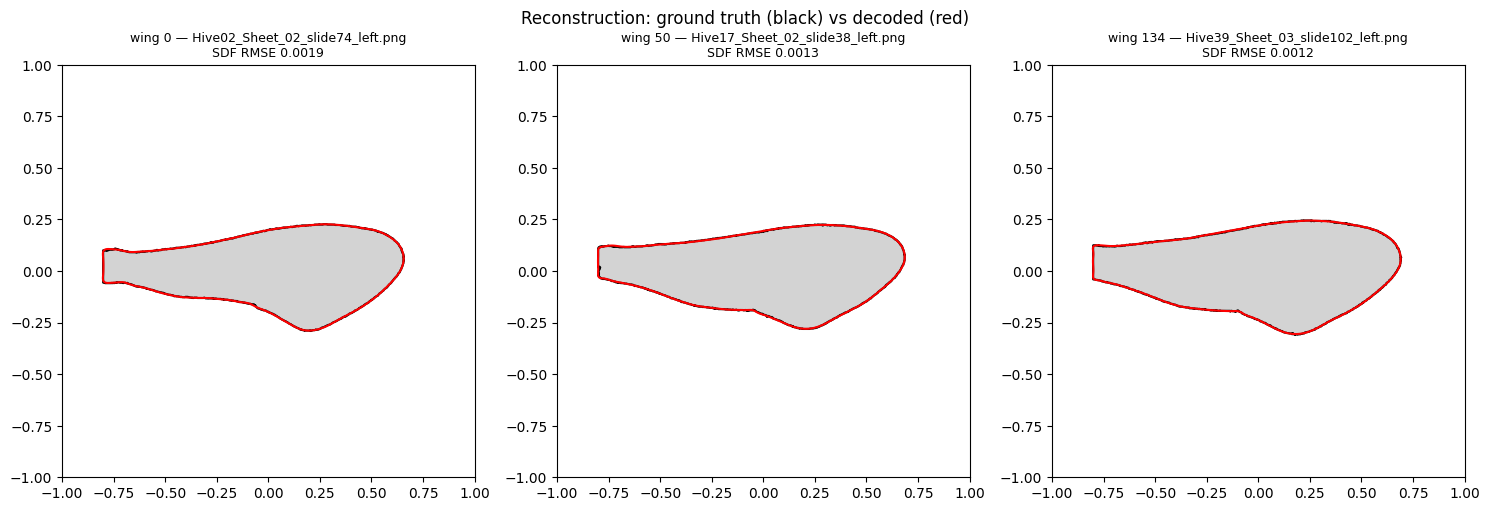

In [ ]:
# =============================================================================
# SANITY CHECK — reconstruction quality after training
# =============================================================================
# Two checks on the trained model, both on training wings (i.e. the fit itself,
# not generalization):
#
#   1. Latent stress. Kruskal stress-1 between distances in latent space and
#      the true L2 shape distances. 0 means the embedding reproduces the shape
#      metric exactly; values below ~0.05 are usually considered a good fit,
#      ~0.1 acceptable. Compare against the stress at initialization to confirm
#      training actually improved the embedding.
#
#   2. Reconstruction. For a few chosen wings, the decoded zero-contour is
#      overlaid on the ground-truth shape. A good model traces the outline
#      closely; systematic gaps mean the network is underfitting, while a
#      ragged or broken contour means the latent code failed to converge.
#
# Diagnostic only — nothing downstream depends on this cell.
# =============================================================================

SANITY_SHAPE_IDS = [0, 50, 134]     # training wing indices to inspect

# --- 1. Latent stress on the training set ---
with torch.no_grad():
    final_stress = np.sqrt(compute_stress(latent_codes.weight, latent_codes.weight,
                                  D_tensor, den, mask=mask).item())

print(f"Training latent stress (Kruskal stress-1): {final_stress:.6f}")
print(f"Trained for {epoch_counter} epochs on {num_train_wings} wings")

# --- 2. Predicted vs ground-truth contours ---
fig, axes = plt.subplots(1, len(SANITY_SHAPE_IDS),
                         figsize=(5 * len(SANITY_SHAPE_IDS), 5))
axes = np.atleast_1d(axes)

for ax, shape_idx in zip(axes, SANITY_SHAPE_IDS):
    true_sdf = train_sdfs[shape_idx]
    pred = predicted_sdf(model, get_z(latent_codes, shape_idx), set_grid)

    X, Y = true_sdf[:, :, 0], true_sdf[:, :, 1]
    Z_true, Z_pred = true_sdf[:, :, 2], pred[:, :, 2]

    # ground truth: filled interior (sdf <= 0) plus its outline
    ax.contourf(X, Y, Z_true, levels=[Z_true.min(), 0], colors=['lightgray'])
    ax.contour(X, Y, Z_true, levels=[0], colors='black', linewidths=1.5)

    # prediction: decoded zero-contour
    ax.contour(X, Y, Z_pred, levels=[0], colors='red', linewidths=1.5)

    rmse = float(np.sqrt(np.mean((Z_pred - Z_true) ** 2)))
    ax.set_title(f"wing {shape_idx} — {train_files[shape_idx]}\nSDF RMSE {rmse:.4f}",
                 fontsize=9)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect('equal')

fig.suptitle('Reconstruction: ground truth (black) vs decoded (red)')
plt.tight_layout()
plt.show()

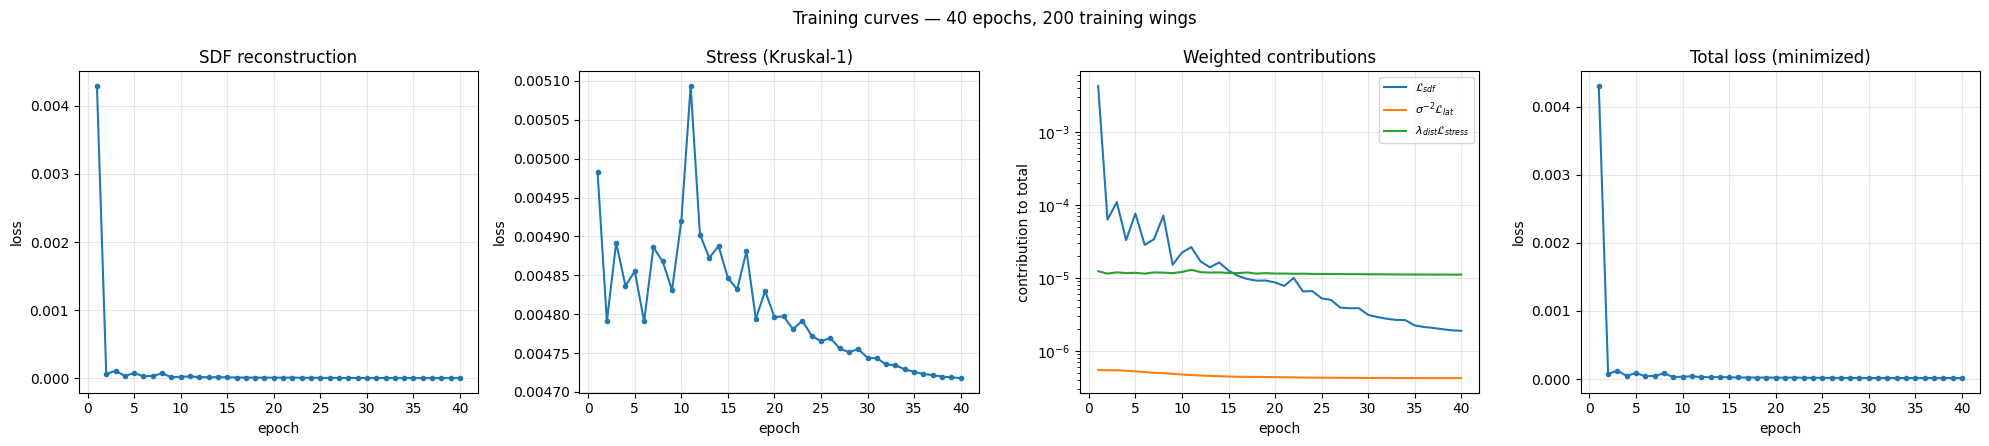

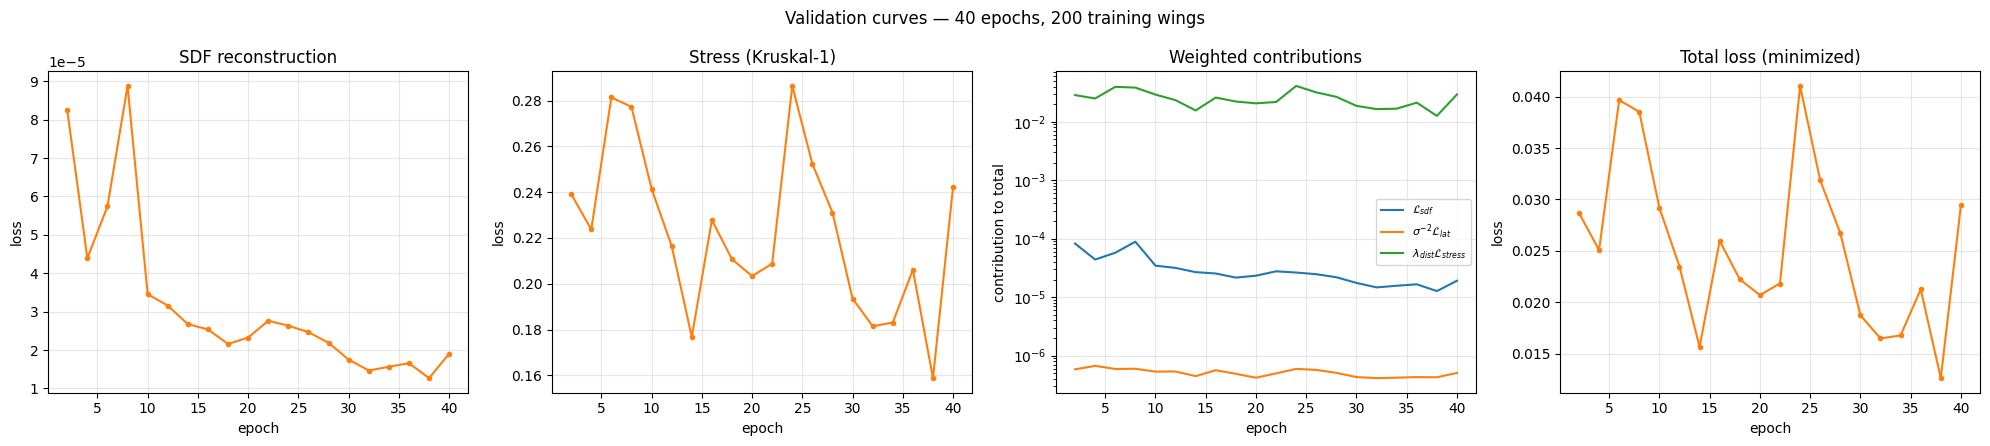

final train | sdf 1.892e-06 | stress 0.004718 | total 1.345e-05
            share of objective — sdf  14.1% | latent   3.2% | stress  82.8%
final val   | sdf 1.906e-05 | stress 0.242471 | total 2.942e-02
            share of objective — sdf   0.1% | latent   0.0% | stress  99.9%


In [ ]:
# =============================================================================
# TRAINING CURVES
# =============================================================================
# Train and validation are plotted as separate figures rather than shared axes,
# because validation losses are much larger in absolute terms and would flatten
# the training curves into a straight line if drawn together.
#
# Four panels per figure:
#   sdf         — reconstruction error. This term alone trains the decoder,
#                 since the other two do not depend on its weights.
#   stress      — Kruskal stress-1: how faithfully latent distances reproduce
#                 true shape distances. Acts on the latent codes only.
#   weighted    — the three terms as they actually enter the objective, i.e.
#                 after their weights, on a log axis. This is the honest view
#                 of what the optimizer sees: the terms differ by orders of
#                 magnitude, so the stress term carries almost all of the total.
#                 They are not in competition for the same parameters, though —
#                 only the latent codes receive gradients from all three.
#   total       — the weighted sum being minimized. Included for completeness;
#                 because it is dominated by the stress term it carries little
#                 information the stress panel does not already show.
#
# The stress curves store Kruskal stress-1 (rooted), while the objective uses
# the un-rooted normalized stress, so the weighted panel squares it back.
#
# Validation runs every VAL_EVERY epochs, so its points are placed on the
# correct epoch numbers rather than against the validation index.
# =============================================================================

train_epochs = np.arange(1, len(train_loss_curve) + 1)
val_epochs   = np.arange(1, len(val_loss_curve) + 1) * VAL_EVERY

# Weighted contributions, as the terms enter the objective
w_sdf_train    = np.array(train_sdf_loss_curve)
w_latent_train = (1 / SIGMA**2) * np.array(train_latent_curve)
w_stress_train = LAMBDA_DIST * np.array(train_stress_curve) ** 2

w_sdf_val    = np.array(val_sdf_loss_curve)
w_latent_val = (1 / SIGMA**2) * np.array(val_latent_curve)
w_stress_val = LAMBDA_DIST * np.array(val_stress_curve) ** 2

figures = [
    ("Training", 'tab:blue', train_epochs,
     train_sdf_loss_curve, train_stress_curve, train_loss_curve,
     w_sdf_train, w_latent_train, w_stress_train),
    ("Validation", 'tab:orange', val_epochs,
     val_sdf_loss_curve, val_stress_curve, val_loss_curve,
     w_sdf_val, w_latent_val, w_stress_val),
]

for (split, color, epochs_axis, sdf_curve, stress_curve, total_curve,
     w_sdf, w_latent, w_stress) in figures:

    if len(epochs_axis) == 0:            # nothing logged for this split yet
        continue

    fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

    # --- individual terms ---
    for ax, title, curve in [(axes[0], 'SDF reconstruction', sdf_curve),
                             (axes[1], 'Stress (Kruskal-1)', stress_curve)]:
        ax.plot(epochs_axis, curve, color=color, marker='o', markersize=3)
        ax.set_title(title)
        ax.set_ylabel('loss')

    # --- weighted contributions to the objective ---
    ax = axes[2]
    ax.plot(epochs_axis, w_sdf,    label=r'$\mathcal{L}_{sdf}$')
    ax.plot(epochs_axis, w_latent, label=r'$\sigma^{-2}\mathcal{L}_{lat}$')
    ax.plot(epochs_axis, w_stress, label=r'$\lambda_{dist}\mathcal{L}_{stress}$')
    ax.set_yscale('log')                 # terms span several orders of magnitude
    ax.set_title('Weighted contributions')
    ax.set_ylabel('contribution to total')
    ax.legend(fontsize=8)

    # --- total ---
    ax = axes[3]
    ax.plot(epochs_axis, total_curve, color=color, marker='o', markersize=3)
    ax.set_title('Total loss (minimized)')
    ax.set_ylabel('loss')

    for ax in axes:
        ax.set_xlabel('epoch')
        ax.grid(alpha=0.3)

    fig.suptitle(f'{split} curves — {epoch_counter} epochs, '
                 f'{num_train_wings} training wings')
    plt.tight_layout()
    plt.show()

# --- final values and the balance between terms ---
for split, sdf_c, stress_c, total_c, ws, wl, wst in [
        ('train', train_sdf_loss_curve, train_stress_curve, train_loss_curve,
         w_sdf_train, w_latent_train, w_stress_train),
        ('val',   val_sdf_loss_curve,   val_stress_curve,   val_loss_curve,
         w_sdf_val, w_latent_val, w_stress_val)]:

    if len(total_c) == 0:
        continue

    total = ws[-1] + wl[-1] + wst[-1]
    print(f"final {split:<5} | sdf {sdf_c[-1]:.3e} | stress {stress_c[-1]:.6f} "
          f"| total {total_c[-1]:.3e}")
    print(f"{'':>12}share of objective — sdf {100*ws[-1]/total:5.1f}% | "
          f"latent {100*wl[-1]/total:5.1f}% | stress {100*wst[-1]/total:5.1f}%")

**PHASE 3 - SHAPE RECONSTRUCTION **

In [ ]:
# =============================================================================
# LOAD CHECKPOINT
# =============================================================================
# Entry point for any session that does not train from scratch. Training may
# have happened much earlier, so this cell rebuilds the decoder and the
# training latent codes from disk; everything below it can then run without
# retraining.
#
# The architecture is rebuilt from the hyperparameters stored *inside* the
# checkpoint, not from the notebook's config cell, so a checkpoint always
# reconstructs the network it was actually trained with. The two are compared
# afterwards and any mismatch is reported: loading a model trained at one grid
# resolution into a session configured for another fails silently and produces
# plausible-looking nonsense.
#
# Requires: the imports cell, and Cell A (SineLayer / SirenDeepSDF2D).
# =============================================================================

checkpoint_path = os.path.join(OUTPUT_ROOT, "sirendeepsdf_checkpoint.pt")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# weights_only=False is needed because the checkpoint also stores config and
# curves, not just tensors. Only load checkpoints you trust.
ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
cfg = ckpt["config"]

# --- Rebuild the decoder with the architecture it was trained with ---
model = SirenDeepSDF2D(latent_dim=cfg["LATENT_DIM"],
                       hidden_dim=cfg["HIDDEN_DIM"],
                       omega0_first=cfg["OMEGA0_FIRST"],
                       omega0_hidden=cfg["OMEGA0_HIDDEN"]).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# --- Restore the training latent codes ---
# Wing count is taken from the saved codes themselves rather than hardcoded.
num_train_wings = ckpt["latent_codes_state_dict"]["weight"].shape[0]
latent_codes = nn.Embedding(num_train_wings, cfg["LATENT_DIM"]).to(device)
latent_codes.load_state_dict(ckpt["latent_codes_state_dict"])

# --- Restore training history, so the curve cells work in a load-only run ---
epoch_counter        = ckpt["epochs_trained"]
train_files          = ckpt["train_files"]
curves               = ckpt["curves"]
train_loss_curve     = curves["train_loss"]
train_sdf_loss_curve = curves["train_sdf"]
train_stress_curve   = curves["train_stress"]
train_latent_curve   = curves["train_latent"]
val_loss_curve       = curves["val_loss"]
val_sdf_loss_curve   = curves["val_sdf"]
val_stress_curve     = curves["val_stress"]
val_latent_curve     = curves["val_latent"]

# --- Report, and warn if the session config disagrees with the checkpoint ---
print(f"Loaded {checkpoint_path}")
print(f"  {num_train_wings} training wings | {epoch_counter} epochs trained")
print(f"  device: {next(model.parameters()).device}")

for name, session_value in [("S", S), ("LATENT_DIM", LATENT_DIM),
                            ("HIDDEN_DIM", HIDDEN_DIM),
                            ("TARGET_SIZE", TARGET_SIZE),
                            ("ROOT_CROP_X", ROOT_CROP_X)]:
    if cfg.get(name) != session_value:
        print(f"  WARNING: {name} is {session_value} in this session "
              f"but {cfg.get(name)} in the checkpoint")

Loaded outputs/sirendeepsdf_checkpoint.pt
  200 training wings | 40 epochs trained
  device: cuda:0


In [ ]:
# =============================================================================
# RECONSTRUCTION COMPONENTS
# =============================================================================
# Functions used by the reconstruction phase, where the decoder is frozen and
# an observed (damaged) wing is explained by finding both a latent code and a
# similarity transform placing that shape onto the observation.
#
# The transform is parameterized as (log_lam, angle, t): log-scale rather than
# scale so it stays positive under unconstrained optimization, and a single
# angle rather than a matrix so the rotation is exactly a rotation.
# =============================================================================

# Smooth (sigmoid) approximation of the Heaviside step. Turns an SDF into a
# soft occupancy field: ~1 inside the shape, ~0 outside, with a transition of
# width ~eps across the boundary. Differentiable, unlike a hard threshold,
# which is what allows the shape to be compared by gradient descent.
def torch_smooth_heaviside(sdf, eps=0.01):
    return torch.sigmoid(-sdf / eps)


# Log-density of z under a Parzen (kernel density) estimate built from the
# training latents. Used as the shape prior: maximizing it keeps the optimized
# code inside the region of latent space the decoder was actually trained on,
# instead of drifting into territory where its output is meaningless.
def parzen_log_density(z, Z_all, sigma=1.0):
    dists_sq = torch.sum((Z_all - z) ** 2, dim=1)
    log_kernels = -dists_sq / (2 * sigma ** 2)
    return torch.logsumexp(log_kernels, dim=0)


# Binary weight mask that discards query points left of the root cut, so the
# region removed from the training shapes is not scored during fitting.
def root_region_weight_from_Xquery(Xquery, root_x=-0.7, root_margin=0.08):
    x = Xquery[:, 0]
    weights = torch.ones_like(x)
    weights[x < root_x + root_margin] = 0.0
    return weights


# Decodes z under a similarity transform, differentiably. Output grid points
# are mapped back into model space by the inverse transform and queried there,
# so gradients flow to log_lam, angle and t as well as to z.
# Returns the SDF values and the query coordinates (needed for spatial weights).
def predicted_sdf_transformed_torch(model, z, coords, log_lam, angle, t):
    lam = torch.exp(log_lam)
    c = torch.cos(angle)
    s = torch.sin(angle)
    R = torch.stack([torch.stack([c, -s]), torch.stack([s, c])])
    Xquery = ((coords - t) @ R) / lam
    z_rep = z.repeat(coords.shape[0], 1)
    sdf_vals = model(z_rep, Xquery).squeeze()
    return sdf_vals, Xquery


# Non-differentiable counterpart of the above, for numpy grids. Returns an
# (S, S, 3) array in the usual (x, y, value) layout.
def predicted_sdf_transformed(model, z, set_grid, lam, R, t):
    model.eval()
    Ycoords = set_grid.reshape(-1, 2)
    Xquery = ((Ycoords - t) @ R) / lam
    coords = torch.tensor(Xquery, dtype=torch.float32).to(device)
    if z.dim() == 1:
        z = z.unsqueeze(0)
    z = z.to(device)
    z_rep = z.repeat(coords.shape[0], 1)
    with torch.no_grad():
        pred_vals = model(z_rep, coords)
    pred_vals = pred_vals.squeeze().cpu().numpy()
    out_flat = np.concatenate([Ycoords, pred_vals[:, None]], axis=1)
    H, W = set_grid.shape[:2]
    return out_flat.reshape(H, W, 3)


# Picks a diverse set of starting latents by clustering the training codes and
# returning, for each cluster centre, the index of the nearest real code. The
# fit is non-convex in z, so the initialization matters; sweeping over spread
# representatives is cheaper than a random restart and covers the space better.
def get_cluster_representatives(Z_all, n_clusters=10, random_state=SEED):
    Z_np = Z_all.detach().cpu().numpy()
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')
    kmeans.fit(Z_np)

    representative_indices = []
    for centroid in kmeans.cluster_centers_:
        dists = np.linalg.norm(Z_np - centroid, axis=1)
        representative_indices.append(int(np.argmin(dists)))
    return representative_indices


# Writes a binary mask as a PNG: shape black on white, matching the convention
# of the input scans. Expects a 2D array in image orientation.
def save_binary_png(binary, save_path):
    img = (1 - binary.astype(np.uint8)) * 255
    Image.fromarray(img).save(save_path)


# Decodes a latent code under a similarity transform and thresholds it into a
# binary mask, returned in image orientation so it overlays the input PNG
# pixel-for-pixel.
def binary_from_transform(model, z, set_grid, lam, angle, t, device):
    coords = torch.tensor(set_grid.reshape(-1, 2), dtype=torch.float32, device=device)
    z = z.to(device)
    if z.dim() == 1:
        z = z.unsqueeze(0)

    log_lam = torch.tensor(np.log(lam), dtype=torch.float32, device=device)
    angle_t = torch.tensor(float(angle), dtype=torch.float32, device=device)
    t_t     = torch.tensor(np.asarray(t), dtype=torch.float32, device=device)

    with torch.no_grad():
        sdf, _ = predicted_sdf_transformed_torch(model, z, coords, log_lam, angle_t, t_t)

    H, W = set_grid.shape[:2]
    binary = (sdf.reshape(H, W).cpu().numpy() <= 0).astype(np.uint8)
    return binary[::-1, :]        # grid -> image orientation


# Keeps only the largest connected component of a binary mask, removing
# speckle and detached fragments.
def keep_largest_component(binary, connectivity=2):
    binary = binary > 0
    structure = (np.array([[0, 1, 0], [1, 1, 1], [0, 1, 0]])
                 if connectivity == 1 else np.ones((3, 3)))
    labeled, num = label(binary, structure=structure)
    if num == 0:
        return binary.astype(np.uint8)
    sizes = np.bincount(labeled.ravel())
    sizes[0] = 0
    return (labeled == sizes.argmax()).astype(np.uint8)


# --- Diagnostics -------------------------------------------------------------

# Overlays the target occupancy field (blue) and the current prediction (red)
# during optimization, to watch the fit converge.
def plot_current_characteristic(model, z, set_grid, chi_y, log_lam, angle, t,
                                device, step, eps_chi=0.005):
    H, W = set_grid.shape[:2]
    coords = torch.tensor(set_grid.reshape(-1, 2), dtype=torch.float32, device=device)
    with torch.no_grad():
        sdf_current, _ = predicted_sdf_transformed_torch(
            model=model, z=z, coords=coords, log_lam=log_lam, angle=angle, t=t)

    C2 = torch_smooth_heaviside(sdf_current.reshape(H, W),
                                eps=eps_chi).detach().cpu().numpy()
    X, Y, C1 = chi_y[:, :, 0], chi_y[:, :, 1], chi_y[:, :, 2]

    plt.figure(figsize=(7, 7))
    extent = [X.min(), X.max(), Y.min(), Y.max()]
    plt.imshow(C1, extent=extent, origin="lower", alpha=0.5, vmin=0, vmax=1)
    plt.imshow(C2, extent=extent, origin="lower", alpha=0.5, vmin=0, vmax=1)
    plt.contour(X, Y, C1, levels=[0.5], colors="blue", linewidths=2)
    plt.contour(X, Y, C2, levels=[0.5], colors="red", linewidths=2)
    plt.scatter([0], [0], color="black", s=25)          # origin
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.gca().set_aspect("equal")
    plt.title(f"target y (blue) vs current prediction (red) | step {step}")
    plt.show()


# Projects the current code onto the 2D PCA of the training latents, showing
# where the optimization has travelled relative to the training distribution.
def plot_current_latent_pca(latent_codes, z, init_shape_idx, step):
    with torch.no_grad():
        Z = latent_codes.weight.detach().cpu().numpy()
        z_np = z.detach().cpu().numpy()
    if z_np.ndim == 1:
        z_np = z_np[None, :]

    pca = PCA(n_components=2)
    Z_2d = pca.fit_transform(Z)
    z_2d = pca.transform(z_np)

    plt.figure(figsize=(8, 8))
    plt.scatter(Z_2d[:, 0], Z_2d[:, 1], color="red", alpha=0.8, label="training latents")
    for idx, (x, y) in enumerate(Z_2d):
        plt.text(x, y, str(idx), fontsize=8)
    plt.scatter(Z_2d[init_shape_idx, 0], Z_2d[init_shape_idx, 1],
                color="green", s=180, edgecolors="black", label="initial latent")
    plt.scatter(z_2d[:, 0], z_2d[:, 1],
                color="blue", s=220, edgecolors="black", label="current estimate")
    plt.title(f"PCA latent space | step {step}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.gca().set_aspect("equal", adjustable="box")
    plt.show()

In [ ]:
# =============================================================================
# RECONSTRUCTION HYPERPARAMETERS
# =============================================================================
# Settings for fitting a latent code and a pose to an observed wing. The
# decoder is frozen throughout; only z and the transform are optimized.
# These are the values used for the results reported in the paper.
# =============================================================================

# --- Initialization sweep ---
N_CLUSTERS   = 10      # candidate starting latents (k-means representatives)
PRE_STEPS    = 30      # pose-only steps per candidate during the sweep

# --- Main optimization ---
OPT_STEPS    = 1000    # joint optimization steps
OPT_LR_G     = 1e-2    # learning rate for the pose (log_lam, angle, t), Adam
OPT_LR_Z     = 1e-4    # learning rate for the latent code, plain gradient step

# --- Data term ---
CHI_EPS      = 0.005   # smooth-Heaviside width; smaller = sharper boundary
LOSS_P       = 2       # exponent of the pointwise occupancy mismatch
OUTSIDE_W    = 0.001   # weight of points outside the observation vs inside

# --- Spatial weighting ---
OPT_ROOT_X      = -0.8    # root cut in query space (matches ROOT_CROP_X)
OPT_ROOT_MARGIN = 0.00    # extra margin discarded beyond the cut
REGION_X_MIN    = -0.75   # emphasized region: lower x bound
REGION_X_MAX    = 0.0     # emphasized region: upper x bound
REGION_WEIGHT   = 5.0     # weight multiplier inside that region

# --- Latent prior ---
PARZEN_MU    = 1e-3    # weight of the Parzen log-density prior
PARZEN_SIGMA = 0.01    # kernel bandwidth; must match the scale of the latent
                       # codes, whose norms are ~1e-2 — a bandwidth of order 1
                       # would make the prior nearly flat and hence inert

# --- Bounds on the pose (keeps the transform physically plausible) ---
LAM_MIN, LAM_MAX = 0.3, 3.0
T_ABS_MAX = 1.0

# --- Reporting ---
PRINT_EVERY = 50       # steps between progress lines
PLOT_EVERY  = 500      # steps between diagnostic plots; None disables

In [ ]:
# =============================================================================
# RECONSTRUCTION — fit a latent code and a pose to an observed wing
# =============================================================================
# Given an image of a damaged wing, finds the shape in the learned manifold
# that best explains it, together with the similarity transform placing that
# shape onto the observation. The decoder is frozen: the observation is
# explained by choosing a point in shape space, never by changing the space.
#
# Phase 1 — initialization sweep. The fit is non-convex in z, so a bad start
#   converges to a bad shape. Several diverse training codes are tried, each
#   given a short pose-only optimization, and the best is kept.
#
# Phase 2 — joint optimization of the pose and the latent code, minimizing
#     data_loss + reg_loss
#   where data_loss is the weighted occupancy mismatch between the decoded
#   shape and the observation, and reg_loss is minus the Parzen log-density of
#   z under the training latents, keeping the code in a region the decoder can
#   be trusted on.
#
# Weighting of the data term reflects what a damaged wing actually tells us:
#   inside_weight  — missing material means the observation is a subset of the
#                    true shape, so predicting material where none is observed
#                    is penalized only lightly (OUTSIDE_W), while failing to
#                    cover observed material is penalized fully.
#   root_mask      — the root region was removed during training and carries
#                    no information, so it is excluded.
#   region_weights — an x-band given extra weight (REGION_WEIGHT).
#
# Outputs are written to a `results/` folder beside the input image:
#   <stem>_1input.png   the observation, binarized
#   <stem>_2model.png   the fitted shape, decoded and transformed
#   <stem>_4opt_result.pt   the full result dict, reloadable with torch.load
# (slot 3 is reserved for ground truth, available only when it exists.)
# =============================================================================

def optimize_theta_and_g(
    y_path,
    model,
    latent_codes,
    rep_indices,
    set_grid,
    device,
    save_outputs=True,
    eps=CHI_EPS,
    p=LOSS_P,
    outside_penalty=OUTSIDE_W,
    mu=PARZEN_MU,
    sigma=PARZEN_SIGMA,
    steps=OPT_STEPS,
    lr_g=OPT_LR_G,
    lr_z=OPT_LR_Z,
    root_x=OPT_ROOT_X,
    root_margin=OPT_ROOT_MARGIN,
    region_x_min=REGION_X_MIN,
    region_x_max=REGION_X_MAX,
    region_weight=REGION_WEIGHT,
    pre_steps=PRE_STEPS,
    print_every=PRINT_EVERY,
    plot_every=PLOT_EVERY,
):
    model.eval()
    for param in model.parameters():
        param.requires_grad_(False)

    # --- Observation: image -> padded binary -> grid -> SDF ---
    # No root crop and no alignment: recovering the pose is the point.
    binary_y = pad_wing(y_path)
    grid_y   = move_image_to_grid(set_grid, binary_y)
    sdf_y    = compute_sdf(grid_y)

    coords = torch.tensor(set_grid.reshape(-1, 2), dtype=torch.float32, device=device)
    sdf_y_torch = torch.tensor(sdf_y[:, :, 2].reshape(-1),
                               dtype=torch.float32, device=device)
    chi_y = torch_smooth_heaviside(sdf_y_torch, eps=eps)

    # Observed material counts fully; unobserved regions only lightly, since
    # damage removes material and cannot add it.
    inside_weight = chi_y + outside_penalty * (1.0 - chi_y)

    Z_all = latent_codes.weight.detach().to(device)

    # --- Shared data term, used by both phases ---
    def compute_data_loss(sdf_pred, Xquery):
        chi_pred = torch_smooth_heaviside(sdf_pred, eps=eps)
        root_mask = root_region_weight_from_Xquery(Xquery=Xquery, root_x=root_x,
                                                   root_margin=root_margin)
        region_weights = torch.ones_like(sdf_pred)
        x_query = Xquery[:, 0]
        region_weights[(x_query >= region_x_min) & (x_query <= region_x_max)] = region_weight

        weights = root_mask * region_weights * inside_weight
        point_loss = torch.abs(chi_y - chi_pred) ** p
        return (1.0 / p) * torch.sum(weights * point_loss) / (weights.sum() + 1e-8)

    # ---------------- PHASE 1: initialization sweep ----------------
    # Each candidate code is held fixed while only the pose is optimized, so
    # candidates are ranked on how well their shape can be positioned.
    def run_short_g_optim(z_candidate):
        z_fixed  = z_candidate.clone().detach()
        _log_lam = torch.tensor(0.0, dtype=torch.float32, device=device, requires_grad=True)
        _angle   = torch.tensor(0.0, dtype=torch.float32, device=device, requires_grad=True)
        _t       = torch.tensor([0.0, 0.0], dtype=torch.float32, device=device, requires_grad=True)
        _optimizer = torch.optim.Adam([_log_lam, _angle, _t], lr=lr_g)

        data_loss = torch.tensor(float('inf'), device=device)
        for _ in range(pre_steps):
            _optimizer.zero_grad()
            sdf_pred, Xquery = predicted_sdf_transformed_torch(
                model=model, z=z_fixed, coords=coords,
                log_lam=_log_lam, angle=_angle, t=_t)
            data_loss = compute_data_loss(sdf_pred, Xquery)
            if torch.isnan(data_loss):
                break
            data_loss.backward()
            torch.nn.utils.clip_grad_norm_([_log_lam, _angle, _t], max_norm=1.0)
            _optimizer.step()
            with torch.no_grad():
                _log_lam.clamp_(np.log(LAM_MIN), np.log(LAM_MAX))
                _t.clamp_(-T_ABS_MAX, T_ABS_MAX)

        return data_loss.item(), _log_lam.detach(), _angle.detach(), _t.detach()

    print(f"--- Coarse sweep over {len(rep_indices)} candidates "
          f"({pre_steps} steps each) ---")

    best_sweep_loss = float('inf')
    best_rep_idx = None
    best_z_init = best_log_lam = best_angle = best_t = None

    for idx in rep_indices:
        z_candidate = Z_all[idx].unsqueeze(0).clone()
        sweep_loss, _log_lam, _angle, _t = run_short_g_optim(z_candidate)
        print(f"  candidate idx={idx:3d} | sweep_loss={sweep_loss:.6f}")
        if sweep_loss < best_sweep_loss:
            best_sweep_loss = sweep_loss
            best_rep_idx    = idx
            best_z_init     = z_candidate
            best_log_lam    = _log_lam.clone()
            best_angle      = _angle.clone()
            best_t          = _t.clone()

    if best_rep_idx is None:
        raise RuntimeError("Sweep failed: every candidate produced NaN.")
    print(f"--- Best candidate idx={best_rep_idx} loss={best_sweep_loss:.6f} ---")

    # ---------------- PHASE 2: joint optimization ----------------
    # The pose is optimized with Adam; the latent code takes a plain gradient
    # step at a much smaller rate, so the shape drifts slowly while the pose
    # adapts quickly. Both are updated from the same backward pass.
    z0      = best_z_init.clone().detach()
    z       = z0.clone().detach().requires_grad_(True)
    log_lam = best_log_lam.clone().requires_grad_(True)
    angle   = best_angle.clone().requires_grad_(True)
    t       = best_t.clone().requires_grad_(True)

    optimizer_g = torch.optim.Adam([{"params": [log_lam, angle, t], "lr": lr_g}])

    losses, data_losses, reg_losses = [], [], []
    best_loss = float('inf')
    best_snapshot = None
    best_step = None

    for step in range(steps):
        optimizer_g.zero_grad()
        if z.grad is not None:
            z.grad.zero_()

        sdf_pred, Xquery = predicted_sdf_transformed_torch(
            model=model, z=z, coords=coords, log_lam=log_lam, angle=angle, t=t)

        data_loss = compute_data_loss(sdf_pred, Xquery)
        reg_loss  = -mu * parzen_log_density(z, Z_all, sigma=sigma)
        loss = data_loss + reg_loss

        if torch.isnan(loss):
            print(f"NaN at step {step}, stopping")
            break

        loss.backward()
        torch.nn.utils.clip_grad_norm_([log_lam, angle, t], max_norm=1.0)
        optimizer_g.step()

        with torch.no_grad():
            if z.grad is not None:
                z -= lr_z * z.grad                    # manual step on the code
            log_lam.clamp_(np.log(LAM_MIN), np.log(LAM_MAX))
            t.clamp_(-T_ABS_MAX, T_ABS_MAX)

        # Keep the best iterate, not the last: the trajectory is not monotone
        if loss.item() < best_loss:
            best_loss = loss.item()
            best_step = step
            best_snapshot = {
                "loss":  loss.item(),
                "lam":   torch.exp(log_lam).detach().cpu().item(),
                "angle": angle.detach().cpu().item(),
                "t":     t.detach().cpu().numpy().copy(),
                "z":     z.detach().cpu().clone(),
            }

        losses.append(loss.item())
        data_losses.append(data_loss.item())
        reg_losses.append(reg_loss.item())

        if print_every and step % print_every == 0:
            z_change    = torch.norm(z - z0).item()
            z_grad_norm = z.grad.norm().item() if z.grad is not None else 0.0
            print(f"step {step:04d} | loss={loss.item():.6f} | "
                  f"data={data_loss.item():.6f} | reg={reg_loss.item():.6f} | "
                  f"z_change={z_change:.4f} | z_grad={z_grad_norm:.6f} | "
                  f"lam={torch.exp(log_lam).item():.4f} | "
                  f"angle={angle.item():.4f} | "
                  f"t=[{t[0].item():.4f}, {t[1].item():.4f}]")

        if plot_every and step % plot_every == 0:
            chi_y_grid = np.concatenate([
                set_grid[:, :, :2],
                chi_y.reshape(set_grid.shape[:2]).detach().cpu().numpy()[:, :, None]
            ], axis=-1)
            plot_current_characteristic(model=model, z=z, set_grid=set_grid,
                                        chi_y=chi_y_grid, log_lam=log_lam,
                                        angle=angle, t=t, device=device, step=step)
            plot_current_latent_pca(latent_codes=latent_codes, z=z,
                                    init_shape_idx=best_rep_idx, step=step)

    results = {
        "loss":            best_snapshot["loss"],
        "lam":             best_snapshot["lam"],
        "angle":           best_snapshot["angle"],
        "t":               best_snapshot["t"],
        "z_optimized":     best_snapshot["z"],
        "z_initial":       z0.detach().cpu(),
        "best_step":       best_step,
        "best_sweep_loss": best_sweep_loss,
        "best_rep_idx":    best_rep_idx,
        "rep_indices":     rep_indices,
        "losses":          losses,
        "data_losses":     data_losses,
        "reg_losses":      reg_losses,
        "input_path":      y_path,
    }

    # ---------------- OUTPUTS ----------------
    if save_outputs:
        results_dir = os.path.join(os.path.dirname(os.path.abspath(y_path)), "results")
        os.makedirs(results_dir, exist_ok=True)
        stem = os.path.splitext(os.path.basename(y_path))[0]

        save_binary_png(binary_y, os.path.join(results_dir, f"{stem}_1input.png"))

        model_binary = binary_from_transform(model, results["z_optimized"], set_grid,
                                             results["lam"], results["angle"],
                                             results["t"], device)
        save_binary_png(model_binary, os.path.join(results_dir, f"{stem}_2model.png"))

        torch.save(results, os.path.join(results_dir, f"{stem}_4opt_result.pt"))
        print(f"Saved results to {results_dir}/{stem}_*")

    return results

In [ ]:
# =============================================================================
# RECONSTRUCTION — run on one observed wing
# =============================================================================
# Candidate starting latents are computed once and can be reused across many
# observations, so this cell can be wrapped in a loop over a directory.
# =============================================================================

set_grid = make_square_grid()
Z_all = latent_codes.weight.detach()
rep_indices = get_cluster_representatives(Z_all, n_clusters=N_CLUSTERS)
print("Candidate latents:", rep_indices)

#y_path = os.path.join(DATA_ROOT, "damaged_wings", "example.png")   # <-- set this
y_path = "reconstruction/HiveC2_Sheet_02_slide33_left_1input.png"
results = optimize_theta_and_g(
    y_path=y_path,
    model=model,
    latent_codes=latent_codes,
    rep_indices=rep_indices,
    set_grid=set_grid,
    device=device,
)

print(f"\nbest loss {results['loss']:.6f} at step {results['best_step']} "
      f"| lam={results['lam']:.4f} angle={results['angle']:.4f} "
      f"| init from wing {results['best_rep_idx']}")

In [ ]:
# =============================================================================
# BATCH RECONSTRUCTION — all artificial damage types
# =============================================================================
# Runs the reconstruction over an evaluation folder containing one subfolder
# per damage type plus `undamaged/`, which holds the intact wings the damaged
# ones were derived from. The nine damage folders are processed; `undamaged/`
# is used only as the source of ground truth, matched by identical filename.
#
# For each damaged wing, four files are written to that folder's `results/`:
#   <stem>_1input.png       the damaged observation, binarized
#   <stem>_2model.png       the reconstruction
#   <stem>_3gt.png          the true undamaged shape, binarized the same way
#   <stem>_4opt_result.pt   the full optimization result
# All four share the canvas and orientation, so they overlay pixel-for-pixel
# and can be compared directly (IoU, pixel counts, contours).
#
# The candidate latents are computed once and reused for every image, so the
# initialization sweep is identical across the whole evaluation.
#
# This is the expensive cell: each image costs roughly 1,300 full-grid decodes,
# so a full run is hours. Failures are logged and skipped rather than stopping
# the run; the summary at the end lists them.
# =============================================================================

EVAL_ROOT = 'FOLDER_HERE'     # <-- set this

DAMAGE_TYPES = [
    "crop_right_50", "angle_45_50", "chunks_50",
    "crop_right_25", "angle_45_25", "chunks_25",
    "crop_right_10", "angle_45_10", "chunks_10",
]
UNDAMAGED_DIR = os.path.join(EVAL_ROOT, "undamaged")

set_grid = make_square_grid()
rep_indices = get_cluster_representatives(latent_codes.weight.detach(),
                                          n_clusters=N_CLUSTERS)
print(f"Candidate latents: {rep_indices}\n")

failures = []
n_done = 0

for damage_type in DAMAGE_TYPES:
    damage_dir = os.path.join(EVAL_ROOT, damage_type)
    files = sorted(f for f in os.listdir(damage_dir) if f.lower().endswith(".png"))
    print(f"=== {damage_type} — {len(files)} wings ===")

    for i, filename in enumerate(files, start=1):
        y_path = os.path.join(damage_dir, filename)
        stem = os.path.splitext(filename)[0]

        try:
            results = optimize_theta_and_g(
                y_path=y_path,
                model=model,
                latent_codes=latent_codes,
                rep_indices=rep_indices,
                set_grid=set_grid,
                device=device,
                print_every=None,
                plot_every=None,
            )

            # Ground truth: the intact wing of the same name, binarized and
            # padded exactly as the input was, so the two are directly comparable.
            gt_binary = pad_wing(os.path.join(UNDAMAGED_DIR, filename))
            save_binary_png(gt_binary,
                            os.path.join(damage_dir, "results", f"{stem}_3gt.png"))

            n_done += 1
            print(f"  [{i:3d}/{len(files)}] {filename} — loss {results['loss']:.6f} "
                  f"| init wing {results['best_rep_idx']} | step {results['best_step']}")

        except Exception as e:
            failures.append((damage_type, filename, repr(e)))
            print(f"  [{i:3d}/{len(files)}] {filename} — FAILED: {e}")

print(f"\nDone: {n_done} wings reconstructed, {len(failures)} failed")
for damage_type, filename, err in failures:
    print(f"  {damage_type}/{filename}: {err}")